/tmp/ipykernel_23434/3713988949.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


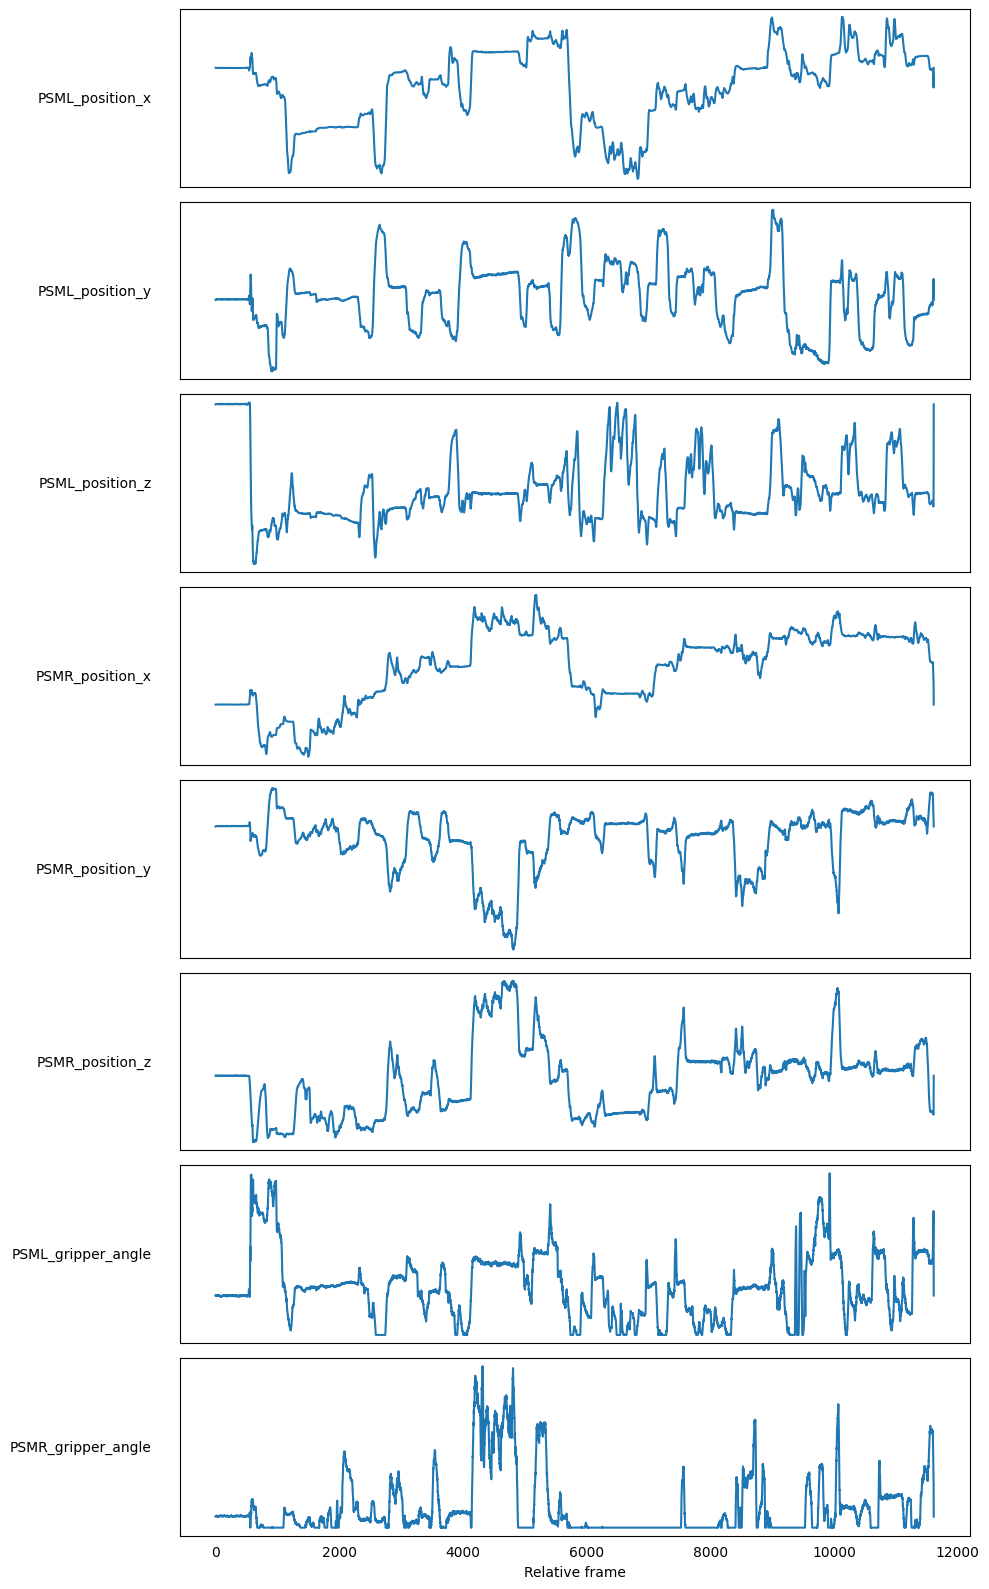

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = './Peg_Transfer_S01_T02_trakStar_final.csv'
data = pd.read_csv(file_path)

# Extract the relative frame and the rest of the columns (excluding some meta-data columns)
relative_frame = data['Relative frame #']
variables = data.drop(columns=['Trackstar time', 'True frame #', 'Frame timestamp', 'Relative frame #'])

# Create subplots for each variable and stack them vertically
fig, axes = plt.subplots(nrows=len(variables.columns), ncols=1, figsize=(10, 2 * len(variables.columns)), sharex=True)

# Plot each variable on its own subplot
for i, column in enumerate(variables.columns):
    axes[i].plot(relative_frame, variables[column])
    axes[i].set_ylabel(column, labelpad=20, rotation=0, ha='right', va='center')
    axes[i].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False)

# Set the x-axis label to 'Relative frame' on the last subplot
axes[-1].set_xlabel('Relative frame')

# Tight layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()


# Raven Kinematics

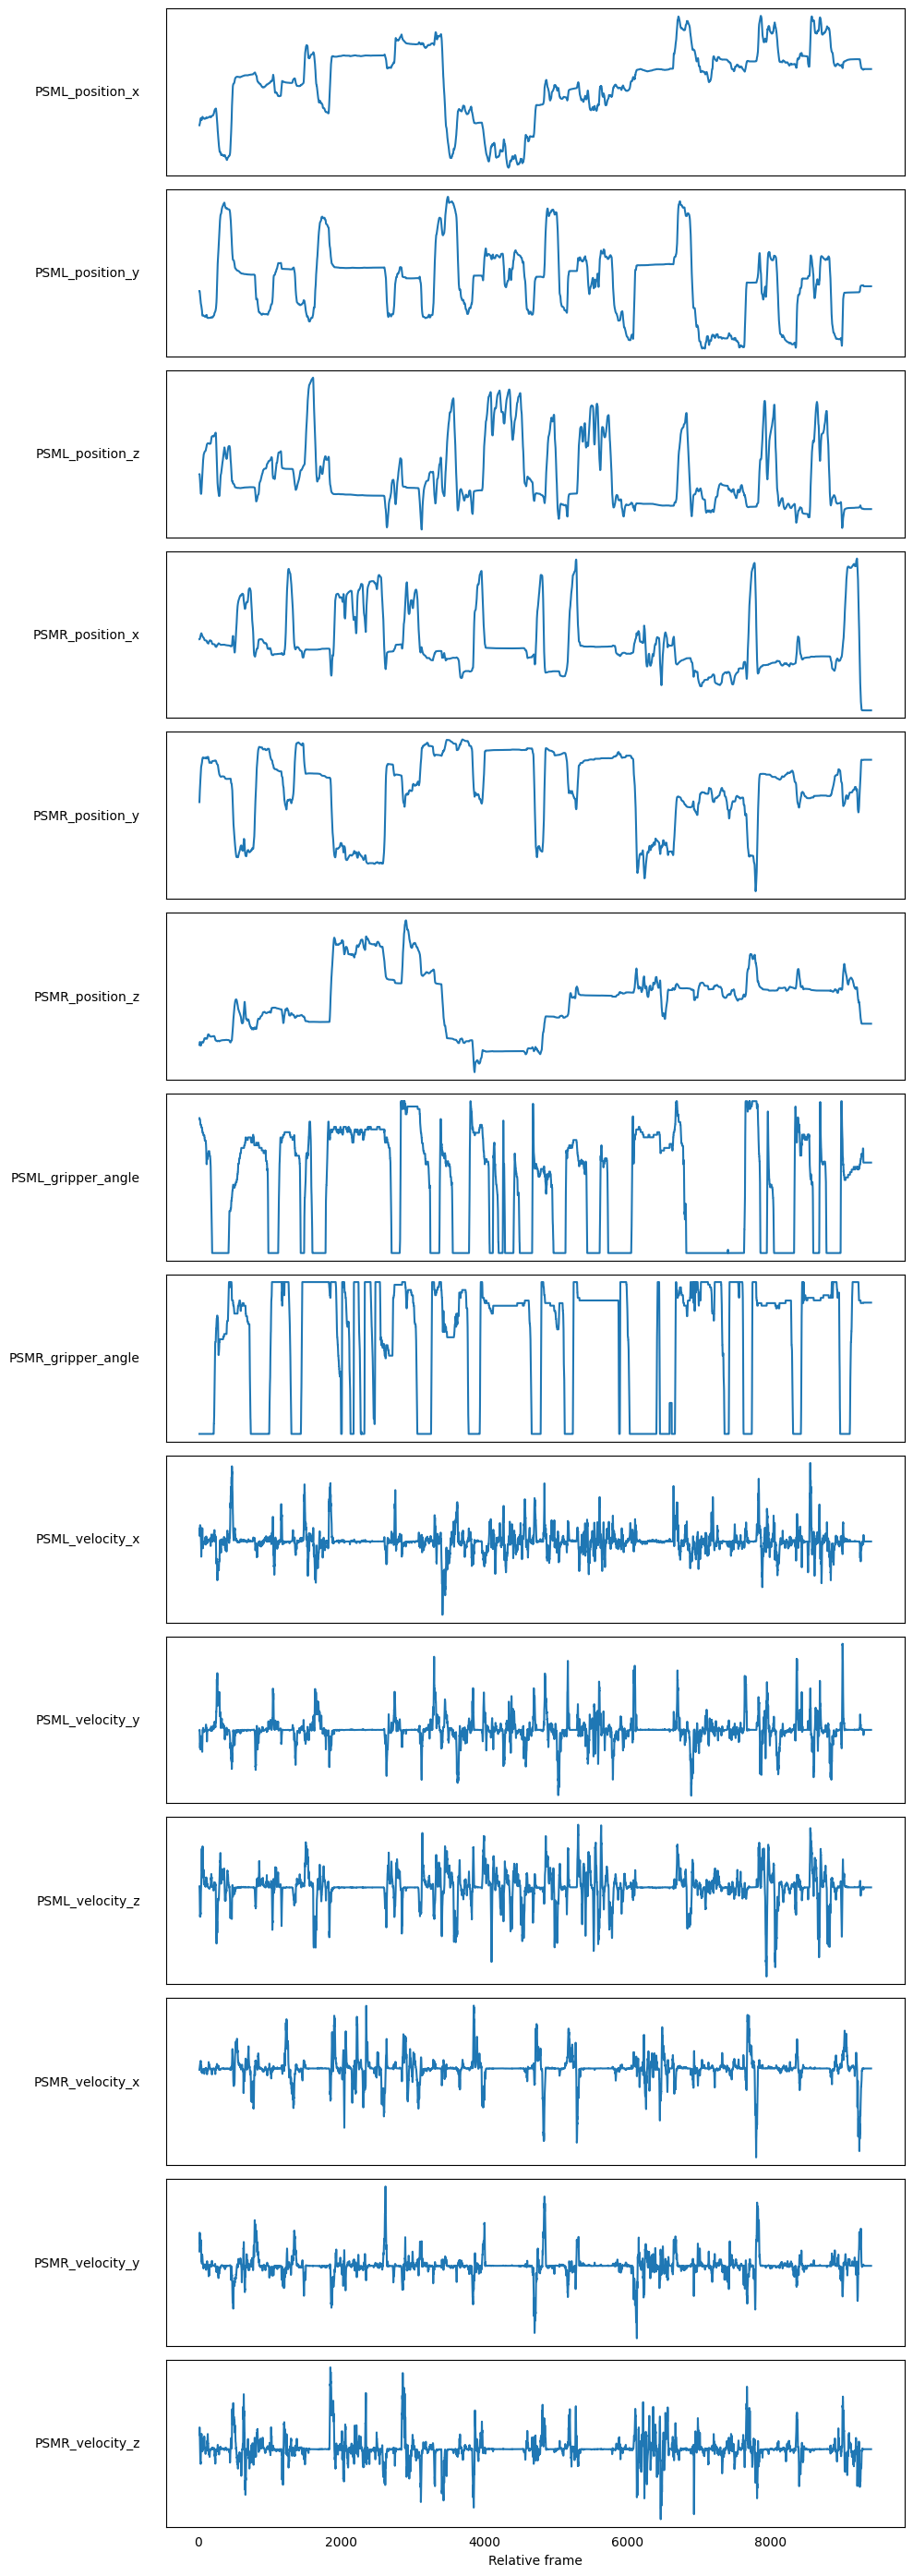

In [4]:
# Load the CSV file
file_path = './Peg_Transfer_S01_T02.csv'
data = pd.read_csv(file_path)

# Extract the relative frame and the rest of the columns (excluding some meta-data columns)
relative_frame = data['Frame']
variables = data.drop(columns=['Timestamp', 'Frame'])

# Create subplots for each variable and stack them vertically
fig, axes = plt.subplots(nrows=len(variables.columns), ncols=1, figsize=(10, 2 * len(variables.columns)), sharex=True)

# Plot each variable on its own subplot
for i, column in enumerate(variables.columns):
    axes[i].plot(relative_frame, variables[column])
    axes[i].set_ylabel(column, labelpad=20, rotation=0, ha='right', va='center')
    axes[i].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False)

# Set the x-axis label to 'Relative frame' on the last subplot
axes[-1].set_xlabel('Relative frame')

# Tight layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()


## Compare Raven vs TrakStar

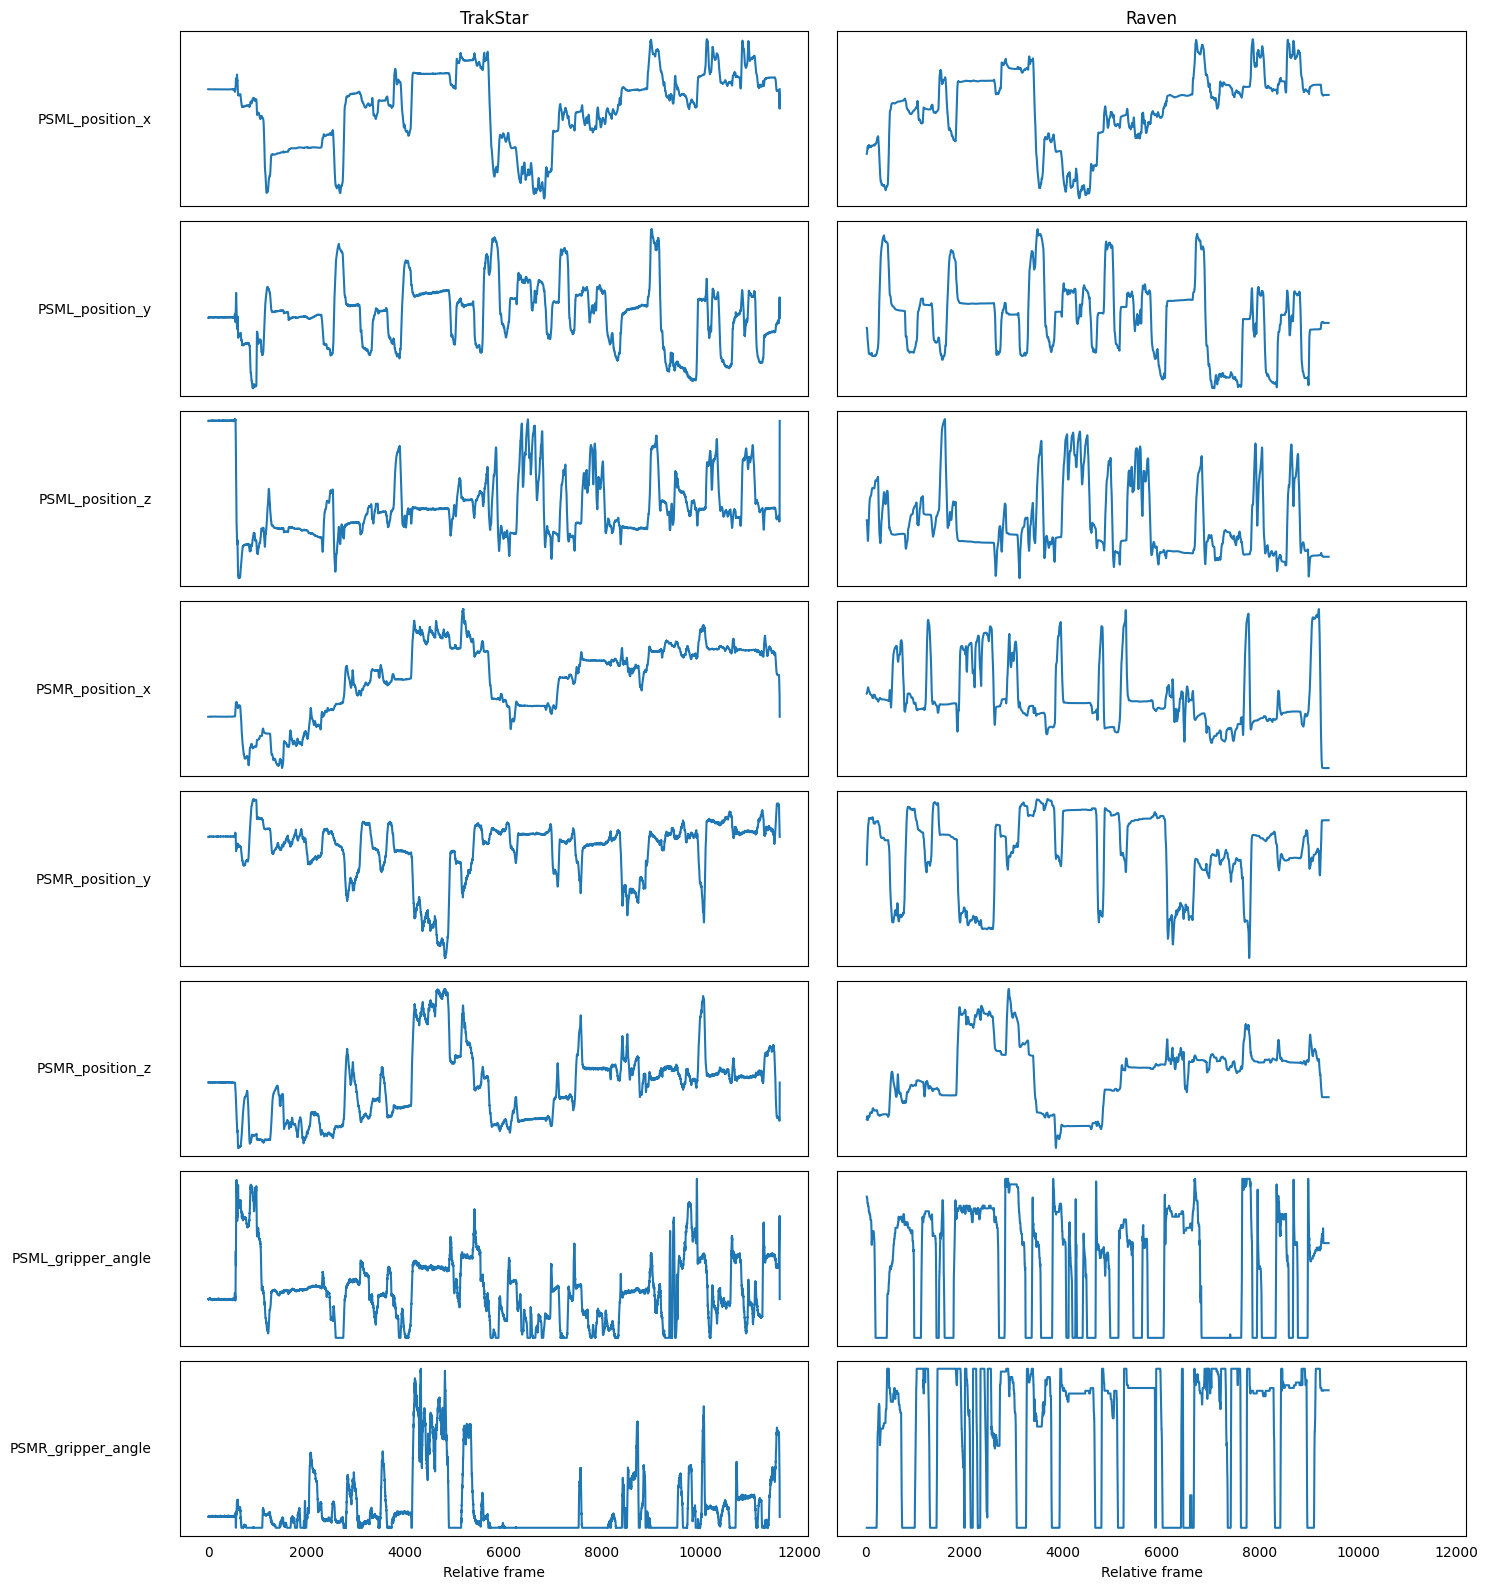

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the original CSV file and the second file
file_path = './Peg_Transfer_S01_T02_trakStar_final.csv'
data = pd.read_csv(file_path)

file_path_2 = './Peg_Transfer_S01_T02.csv'
data_2 = pd.read_csv(file_path_2)

# Extracting the 'variables' from the first dataset
relative_frame = data['Relative frame #']
variables = data.drop(columns=['Trackstar time', 'True frame #', 'Frame timestamp', 'Relative frame #'])

# Renaming the common columns in the second dataset to match for easier comparison
data_2_renamed = data_2.rename(columns={
    'Frame': 'Relative frame #',
    'PSML_position_x': 'PSML_position_x',
    'PSML_position_y': 'PSML_position_y',
    'PSML_position_z': 'PSML_position_z',
    'PSMR_position_x': 'PSMR_position_x',
    'PSMR_position_y': 'PSMR_position_y',
    'PSMR_position_z': 'PSMR_position_z',
    'PSML_gripper_angle': 'PSML_gripper_angle',
    'PSMR_gripper_angle': 'PSMR_gripper_angle'
})

# Extract only relevant columns for comparison
data_2_filtered = data_2_renamed[['Relative frame #', 'PSML_position_x', 'PSML_position_y', 'PSML_position_z', 
                                  'PSMR_position_x', 'PSMR_position_y', 'PSMR_position_z', 
                                  'PSML_gripper_angle', 'PSMR_gripper_angle']]

# Create subplots for each variable and plot them side by side
fig, axes = plt.subplots(nrows=len(variables.columns), ncols=2, figsize=(15, 2 * len(variables.columns)), sharex=True)

# Define a color palette to ensure the same colors for both datasets
colors = plt.get_cmap('tab10').colors
# Plot each variable from both datasets on their respective subplots
for i, column in enumerate(variables.columns):
    # Plot for the first dataset
    axes[i, 0].plot(relative_frame, variables[column])
    axes[i, 0].set_ylabel(column, labelpad=20, rotation=0, ha='right', va='center')
    axes[i, 0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False)
    
    # Plot for the second dataset
    axes[i, 1].plot(data_2_filtered['Relative frame #'], data_2_filtered[column])
    axes[i, 1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False)

# Set the x-axis label to 'Relative frame' on the last subplot
axes[-1, 0].set_xlabel('Relative frame')
axes[-1, 1].set_xlabel('Relative frame')

# Add titles to differentiate the datasets
axes[0, 0].set_title('TrakStar')
axes[0, 1].set_title('Raven')

# Tight layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()
